In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from dataclasses import replace

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import PALETTES
from converters.img_converter import ImgConverter
from converters.line_heuristics.line_converter import LineConverter
from converters.tile.bin_2d import Tile2Symb2dBin

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = PALETTES['asciis']
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
MAX_COLS = 20
MAX_LINES = 10
NUM_IMGS = 100
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


def make_converter(params: Params):
    converter = LineConverter(tile_converter=Tile2Symb2dBin(symbols=SYMBOLS,
                                                            font=FONT,
                                                            **params.converter_args))

    return ImgConverter(converter, FONT)

In [2]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery

default_params = Params(max_cols=MAX_COLS,
                        max_lines=MAX_LINES,
                        font_path=FONT_PATH,
                        font_size=FONT_SIZE)

converter = make_converter(default_params)

results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    gens_per_step=default_params.gens_per_step)
    results.append(res_arr)

print_gallery(results, 3)

----------------------------------------------------------------------
| "+++++++++++++++++_; | u%6Wpaajuwaq@@@@ap@0 | ]22o[+++++y+j+ya2];; |
| ++++++++____________ | v+++waaj+2cSoaI2c1[+ | +++++_+++++++____;;; |
| awppppppppppppppppaa | +++jpwui++:/+c+++y++ | ++++cjaayapay++++aay |
| app@@l++xmppppppwwaa | jcjupqw+_~ `+yayyaaj | ++c+cc1ucuyuuuu24ca] |
| awppaaqaqppppppppaaa | +ayyawaa+.' caaay+j+ | +++++:;+++x++++++++, |
| appggggg@@gggppqaaaa | +jjuaaaa+'!_y11uaaa+ | +++++`+++!+:;;____++ |
| w@@@@@@@@@@@pwwwwaau | jjjcoaaac,+u+;+xcjj+ | ++L+_;__+__++yaaaaaa |
----------------------------------------------------------------------
--------------------------------------------------------------
|  `:-`;,; ;   | pa@gwpggayyy@@a+yaaw | yy+++++uuuuyjyyjj+++ |
| ;;________,, | pgqppyawppppw$Qp$@@@ | aaaaej++++++c1icLscc |
| jjuuuujjjjj+ | a@p@gqqaa+yj+u2+"?eq | ay++++c+cjjaa++c++++ |
| aaaaaaaaauu+ | pa@@@@@@w4++c+!!~ `+ | aaaaaa+++"+uuc+yauj+ |
| yyaacj+jaay+ | 1++a@aap+__+!:_'-:-: | aaaayy

Min: -0.0196 | Max: 0.1118 | Mean: 0.0430 | Std: 0.0263
Min: 0.0326 | Max: 0.1856 | Mean: 0.1201 | Std: 0.0318
Min: 0.0265 | Max: 0.2152 | Mean: 0.1240 | Std: 0.0396
Min: 0.0209 | Max: 0.2220 | Mean: 0.1184 | Std: 0.0436
Min: 0.0167 | Max: 0.2198 | Mean: 0.1179 | Std: 0.0443
Min: 0.0152 | Max: 0.1763 | Mean: 0.1036 | Std: 0.0327
Min: 0.0136 | Max: 0.2397 | Mean: 0.1054 | Std: 0.0352
Min: -0.0018 | Max: 0.2736 | Mean: 0.1094 | Std: 0.0395
Min: 0.0248 | Max: 0.1779 | Mean: 0.1088 | Std: 0.0327


C:\Users\wojte\AppData\Local\Temp\ipykernel_25592\910520446.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


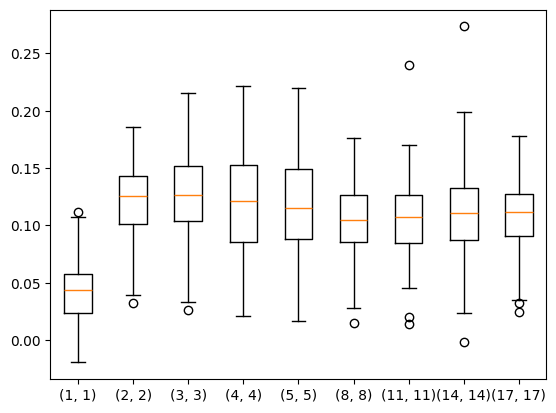

In [3]:
# bins

params_space = [
    (bins, bins) for bins in range(1, 5, 1)
]
params_space += [
    (bins, bins) for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: replace(default_params, converter_args={'bins': bins}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: -0.0024 | Max: 0.1514 | Mean: 0.0850 | Std: 0.0321
Min: 0.0386 | Max: 0.2155 | Mean: 0.1135 | Std: 0.0344
Min: 0.0216 | Max: 0.2736 | Mean: 0.1279 | Std: 0.0441
Min: 0.0459 | Max: 0.2699 | Mean: 0.1445 | Std: 0.0459
Min: 0.0262 | Max: 0.2708 | Mean: 0.1543 | Std: 0.0465


C:\Users\wojte\AppData\Local\Temp\ipykernel_25592\2305421242.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


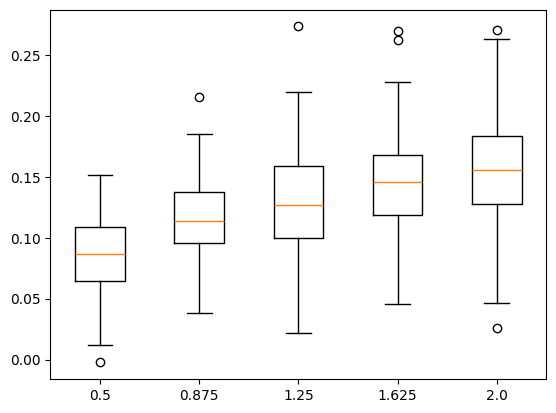

In [4]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: replace(default_params, preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

Min: 0.0207 | Max: 0.2436 | Mean: 0.1073 | Std: 0.0356
Min: -0.0139 | Max: 0.1377 | Mean: 0.0646 | Std: 0.0319
Min: -0.0016 | Max: 0.4266 | Mean: 0.1235 | Std: 0.0834


C:\Users\wojte\AppData\Local\Temp\ipykernel_25592\1162874657.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


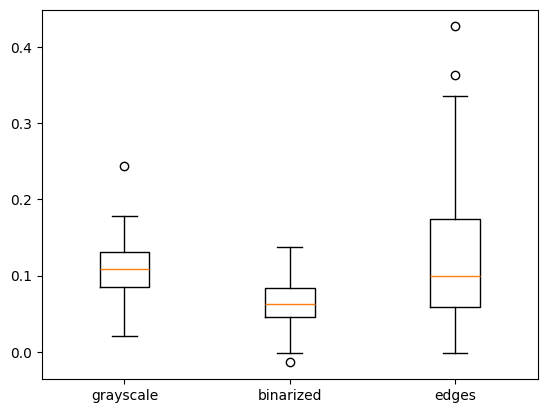

In [5]:
params_space = [default_params]
similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
             for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_BIN_PATHS, make_converter, params_space)

IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
             for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_EDGE_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=['grayscale', 'binarized', 'edges'])
plt.show()

Min: 0.0177 | Max: 0.3077 | Mean: 0.1186 | Std: 0.0455
Min: -0.0174 | Max: 0.1675 | Mean: 0.0825 | Std: 0.0371
Min: 0.0198 | Max: 0.3290 | Mean: 0.1166 | Std: 0.0586


C:\Users\wojte\AppData\Local\Temp\ipykernel_25592\918691062.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


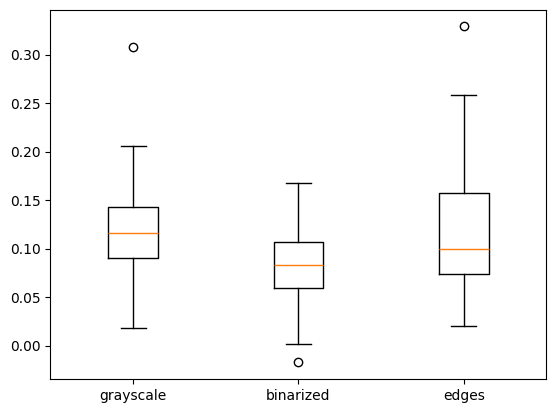

In [6]:
EXTENDED_SYMBOLS = PALETTES['extended-asciis']

def make_converter(params: Params):
    converter = LineConverter(tile_converter=Tile2Symb2dBin(symbols=EXTENDED_SYMBOLS,
                                                            font=FONT,
                                                            **params.converter_args))

    return ImgConverter(converter, FONT)

params_space = [default_params]
similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
             for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_BIN_PATHS, make_converter, params_space)

IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
             for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_EDGE_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=['grayscale', 'binarized', 'edges'])
plt.show()